In [17]:
from IPython.display import display
import numpy as np
import matplotlib.pyplot as plt

pop_size = int(1e7)

display(f"Population size: {pop_size}")

population = (4*np.random.randn(pop_size))**2

#display(population)

pop_mean = np.mean(population)
display(f"Population mean: {pop_mean}")


'Population size: 10000000'

'Population mean: 15.986783201617742'

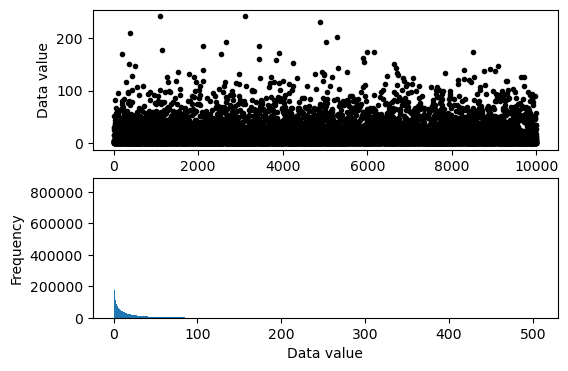

In [9]:
fig, ax = plt.subplots(2,1, figsize=(6,4))

ax[0].plot(population[::1000], 'k.')
ax[0].set_xlabel('Data index')
ax[0].set_ylabel('Data value')

ax[1].hist(population, bins='fd')
ax[1].set_xlabel('Data value')
ax[1].set_ylabel('Frequency')

plt.show()

'Sample mean: 23.274484571908253'

'Sample standard deviation: 26.732627349427098'

'Confidence interval tail probability: 0.025000000000000022'

'95% confidence interval: [14.72497558 31.82399357]'

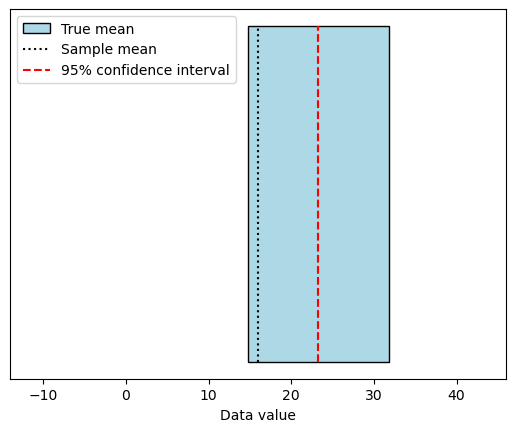

In [27]:
from scipy import stats

sample_size = 40
confidence = 95

# Randomly sample indices from the population as per the sample size
random_sample = np.random.randint(0, pop_size, sample_size) 

#display(random_sample)

sample_data = population[random_sample]

#display(sample_data)

sample_mean = np.mean(sample_data)
display(f"Sample mean: {sample_mean}")
sample_std = np.std(sample_data, ddof=1)
display(f"Sample standard deviation: {sample_std}")

citmp = (1-confidence/100)/2
display(f"Confidence interval tail probability: {citmp}")

confidence_interval = sample_mean + stats.t.ppf([citmp, 1-citmp], sample_size-1)*sample_std/np.sqrt(sample_size)
display(f"{confidence}% confidence interval: {confidence_interval}")

from matplotlib.patches import Polygon


fig, ax = plt.subplots(1,1)

y = np.array([[confidence_interval[0], 0], [confidence_interval[1], 0], 
              [confidence_interval[1], 1], [confidence_interval[0], 1]])

p = Polygon(y, facecolor='lightblue', edgecolor='k')
ax.add_patch(p)

ax.plot([pop_mean, pop_mean], [0, 1], 'k:', label='Population mean')
ax.plot([sample_mean, sample_mean], [0, 1], 'r--', label='Sample mean')
ax.set_xlim([pop_mean-30, pop_mean+30])
ax.set_yticks([])
ax.set_xlabel('Data value')
ax.legend(['True mean', 'Sample mean', '%g%% confidence interval' % confidence])
plt.show()





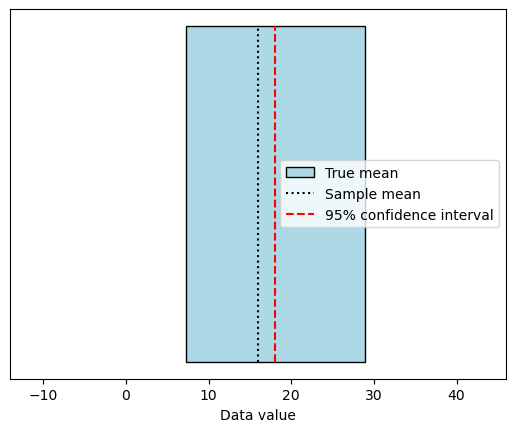